In [20]:
# HEALTHCARE AI ASSISTANT (FINAL VERSION)
# =========================================

import numpy as np
import re
from datetime import datetime
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# =========================================

In [21]:
# =========================================
# 1. MEDICAL KNOWLEDGE BASE
# =========================================
medical_docs = [
    {"condition": "Diabetes",
     "text": "frequent urination fatigue thirst blurred vision weight loss"},
    {"condition": "Hypertension",
     "text": "high blood pressure headache dizziness nosebleeds"},
    {"condition": "Asthma",
     "text": "breathing difficulty wheezing chest tightness cough"},
    {"condition": "Migraine",
     "text": "severe headache nausea vomiting light sensitivity"},
    {"condition": "COVID-19",
     "text": "fever cough fatigue loss of smell sore throat"},
    {"condition": "Anemia",
     "text": "fatigue pallor dizziness cold hands shortness breath"},
    {"condition": "Pneumonia",
     "text": "fever cough chest pain breathing difficulty chills"},
    {"condition": "UTI",
     "text": "burning urination pelvic pain cloudy urine"},
    {"condition": "Depression",
     "text": "sadness low energy sleep problems hopelessness"},
    {"condition": "Appendicitis",
     "text": "sharp lower right abdomen pain nausea fever"}
]

corpus = [d["text"] for d in medical_docs]


In [22]:

# =========================================
# 2. TF-IDF
# =========================================
vectorizer = TfidfVectorizer(ngram_range=(1,2), stop_words="english")
doc_vectors = vectorizer.fit_transform(corpus)


In [23]:
SYNONYMS = {
    "tired": "fatigue",
    "weak": "fatigue",
    "vomiting": "nausea",
    "throwing up": "nausea",
    "pee": "urination",
    "toilet": "urination",
    "breathless": "breathing difficulty",
    "sad": "depression",
    "no interest": "depression",
    "chest tight": "chest tightness",
    "feeling cold": "cold hands",
}

In [24]:
def preprocess(query):
    query = query.lower()
    query = re.sub(r"[^a-z0-9\s]", " ", query)

    words = query.split()
    expanded = []

    for w in words:
        if w in SYNONYMS:
            expanded.append(SYNONYMS[w])
        expanded.append(w)

    return " ".join(expanded)

In [25]:
# 4. HYBRID RETRIEVAL (CORE IMPROVEMENT)
# =========================================
def retrieve(query, top_k=3):
    clean = preprocess(query)
    query_vec = vectorizer.transform([clean])
    tfidf_scores = cosine_similarity(query_vec, doc_vectors)[0]

    query_tokens = set(clean.split())
    scores = []

    for i, doc in enumerate(medical_docs):
        doc_tokens = set(doc["text"].split())

        # 🔹 keyword overlap
        overlap = len(query_tokens & doc_tokens)
        keyword_score = overlap / (len(query_tokens) + 1e-5)

        # 🔹 base hybrid score
        final_score = 0.6 * tfidf_scores[i] + 0.4 * keyword_score

        # 🔥 ADD BOOST HERE (THIS IS THE LINE YOU ASKED)
        if "pain" in query_tokens and "pain" in doc_tokens:
            final_score += 0.05

        scores.append(final_score)

    scores = np.array(scores)
    top_idx = scores.argsort()[-top_k:][::-1]

    return [(medical_docs[i], scores[i]) for i in top_idx]

In [26]:
# 5. CONFIDENCE
# =========================================
def classify_conf(score):
    if score >= 0.60:
        return "HIGH"
    elif score >= 0.35:
        return "MEDIUM"
    elif score >= 0.20:
        return "LOW"
    else:
        return "NONE"


In [27]:
# =========================================
# 6. SAFETY LAYER
# =========================================
def safety_check(text):
    unsafe = ["overdose", "high dosage", "guaranteed cure"]
    for w in unsafe:
        if w in text.lower():
            return "⚠️ Unsafe advice detected"
    return None


In [28]:
# 7. ACCURACY TRACKER
# =========================================
class Tracker:
    def __init__(self):
        self.total = 0
        self.correct = 0

    def update(self, pred, actual):
        self.total += 1
        if pred.lower() == actual.lower():
            self.correct += 1

    def accuracy(self):
        return round((self.correct/self.total)*100,2) if self.total else 0

tracker = Tracker()


In [29]:
# 8. MAIN FUNCTION
# =========================================
def ask(query, actual=None):
    print("\n" + "="*50)
    print("Query:", query)

    results = retrieve(query)
    best_doc, score = results[0]

    confidence = classify_conf(score)

    print("\n💡 Predicted Condition:", best_doc["condition"])
    print(f"📊 Confidence Score: {round(score*100,2)}% ({confidence})")

    # safety
    warning = safety_check(best_doc["text"])
    if warning:
        print(warning)

    print("\n📚 Top Matches:")
    for doc, s in results:
        print(f"- {doc['condition']} ({round(s*100,2)}%)")

    # accuracy tracking
    if actual:
        tracker.update(best_doc["condition"], actual)
        print(f"\n🎯 Running Accuracy: {tracker.accuracy()}%")


In [30]:
# 9. TEST SUITE
# =========================================
def run_test():
    tests = [
    ("I feel very tired and keep going to toilet again and again", "Diabetes"),
    ("my head hurts badly and I feel like vomiting in bright light", "Migraine"),
    ("I have high BP and sometimes nose bleeding", "Hypertension"),
    ("burning sensation while peeing and lower stomach pain", "UTI"),
    ("fever with cough and breathing problem", "Pneumonia"),
    ("difficulty breathing and chest tightness during exercise", "Asthma"),
    ("feeling very sad and no interest in anything", "Depression"),
    ("extreme weakness and pale skin", "Anemia"),
    ("pain in lower right stomach and nausea", "Appendicitis"),
    ("loss of smell with fever and cough", "COVID-19")]


    print("\nRunning Accuracy Test...\n")

    for q, ans in tests:
        ask(q, ans)

    print("\nFinal Accuracy:", tracker.accuracy(), "%")


In [31]:
# =========================================
# 10. RUN (Notebook version)
# =========================================

print("Healthcare AI Assistant")

ask("severe headache nausea")

# run evaluation
run_test()

Healthcare AI Assistant

Query: severe headache nausea

💡 Predicted Condition: Migraine
📊 Confidence Score: 79.14% (HIGH)

📚 Top Matches:
- Migraine (79.14%)
- Hypertension (19.7%)
- Appendicitis (19.31%)

Running Accuracy Test...


Query: I feel very tired and keep going to toilet again and again

💡 Predicted Condition: Diabetes
📊 Confidence Score: 24.78% (LOW)

📚 Top Matches:
- Diabetes (24.78%)
- UTI (15.31%)
- COVID-19 (12.15%)

🎯 Running Accuracy: 100.0%

Query: my head hurts badly and I feel like vomiting in bright light

💡 Predicted Condition: Migraine
📊 Confidence Score: 45.05% (MEDIUM)

📚 Top Matches:
- Migraine (45.05%)
- Appendicitis (9.61%)
- Depression (0.0%)

🎯 Running Accuracy: 100.0%

Query: I have high BP and sometimes nose bleeding

💡 Predicted Condition: Hypertension
📊 Confidence Score: 23.56% (LOW)

📚 Top Matches:
- Hypertension (23.56%)
- Appendicitis (0.0%)
- Depression (0.0%)

🎯 Running Accuracy: 100.0%

Query: burning sensation while peeing and lower stomach pai

In [32]:
pip install matplotlib seaborn scikit-learn

In [33]:

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

def evaluate_model():
    test_cases = [
    ("I feel very tired and keep going to toilet again and again", "Diabetes"),
    ("my head hurts badly and I feel like vomiting in bright light", "Migraine"),
    ("I have high BP and sometimes nose bleeding", "Hypertension"),
    ("burning sensation while peeing and lower stomach pain", "UTI"),
    ("fever with cough and breathing problem", "Pneumonia"),
    ("difficulty breathing and chest tightness during exercise", "Asthma"),
    ("feeling very sad and no interest in anything", "Depression"),
    ("extreme weakness and pale skin", "Anemia"),
    ("pain in lower right stomach and nausea", "Appendicitis"),
    ("loss of smell with fever and cough", "COVID-19")
]

    y_true = []
    y_pred = []

    for q, actual in test_cases:
        results = retrieve(q)
        pred = results[0][0]["condition"]

        y_true.append(actual)
        y_pred.append(pred)

    # ===== Accuracy =====
    acc = sum([1 for i in range(len(y_true)) if y_true[i] == y_pred[i]]) / len(y_true)
    print(f"\nAccuracy: {round(acc*100,2)}%")

    # ===== Confusion Matrix =====
    labels = list(set(y_true))
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    plt.figure()
    sns.heatmap(cm, annot=True, fmt="d", xticklabels=labels, yticklabels=labels)
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # ===== Accuracy Bar Graph =====
    plt.figure()
    plt.bar(["Accuracy"], [acc*100])
    plt.title("Model Accuracy")
    plt.ylabel("Percentage")
    plt.show()

    # ===== Report =====
    print("\nClassification Report:\n")
    print(classification_report(y_true, y_pred))


Accuracy: 80.0%


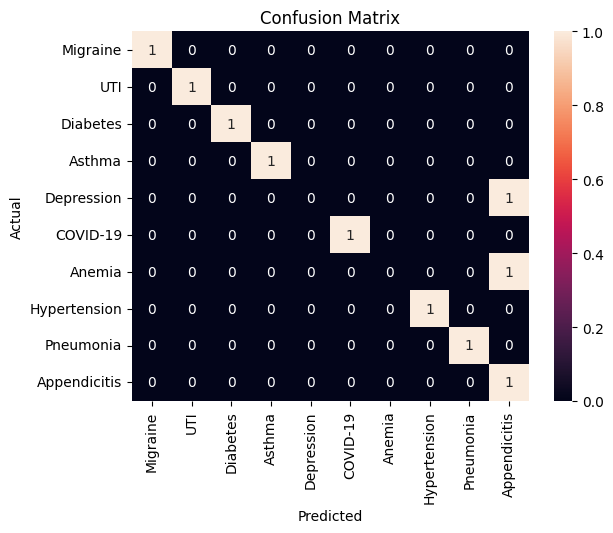

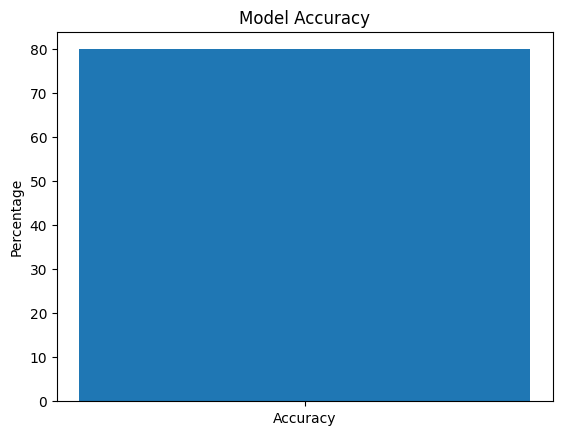


Classification Report:

              precision    recall  f1-score   support

      Anemia       0.00      0.00      0.00         1
Appendicitis       0.33      1.00      0.50         1
      Asthma       1.00      1.00      1.00         1
    COVID-19       1.00      1.00      1.00         1
  Depression       0.00      0.00      0.00         1
    Diabetes       1.00      1.00      1.00         1
Hypertension       1.00      1.00      1.00         1
    Migraine       1.00      1.00      1.00         1
   Pneumonia       1.00      1.00      1.00         1
         UTI       1.00      1.00      1.00         1

    accuracy                           0.80        10
   macro avg       0.73      0.80      0.75        10
weighted avg       0.73      0.80      0.75        10



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [34]:
evaluate_model()